# 05 — Compare KeyDiffPress vs vLLM on NIAH

This notebook loads the results from notebooks 02 (kvpress/KeyDiffPress) and
04 (vLLM baseline), then produces:

1. **NIAH heatmaps** — ROUGE-L score by needle depth and compression ratio
2. **Memory comparison** — peak GPU memory per configuration
3. **Latency comparison** — inference time distributions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

## 1. Load Results

In [2]:
kvpress_df = pd.read_csv("results/kvpress/predictions.csv")
vllm_df = pd.read_csv("results/vllm/predictions.csv")

df = pd.concat([kvpress_df, vllm_df], ignore_index=True)

print(f"Loaded {len(kvpress_df)} kvpress + {len(vllm_df)} vllm = {len(df)} total results")
df.head()

Loaded 80 kvpress + 80 vllm = 160 total results


,framework,press,compression_ratio,max_context_length,needle_depth,needle,question,predicted_answer,elapsed_sec,peak_gpu_mem_gb,task,rouge_l_f
0,kvpress,full_replacement,0.01,4096,0,"\n\nRemember, the best thing to do in San Fran...",\n\nQuestion: Based on the content of the book...,**eat a sandwich and sit in Dolores Park on a...,1.823,17.399,needle_in_haystack,0.705882
1,kvpress,full_replacement,0.01,4096,25,"\n\nRemember, the best thing to do in San Fran...",\n\nQuestion: Based on the content of the book...,**eat a sandwich and sit in Dolores Park on a...,1.371,17.399,needle_in_haystack,0.705882
2,kvpress,full_replacement,0.01,4096,50,"\n\nRemember, the best thing to do in San Fran...",\n\nQuestion: Based on the content of the book...,to eat a sandwich and sit in Dolores Park on ...,1.313,17.399,needle_in_haystack,0.742857
3,kvpress,full_replacement,0.01,4096,75,"\n\nRemember, the best thing to do in San Fran...",\n\nQuestion: Based on the content of the book...,to eat a sandwich and sit in Dolores Park on ...,1.323,17.399,needle_in_haystack,0.742857
4,kvpress,full_replacement,0.01,4096,100,"\n\nRemember, the best thing to do in San Fran...",\n\nQuestion: Based on the content of the book...,to eat a sandwich and sit in Dolores Park on ...,1.323,17.399,needle_in_haystack,0.742857


## 2. NIAH Heatmaps — ROUGE-L by Needle Depth and Compression Ratio

One heatmap per (press_type, max_context_length) combination,
plus the vLLM baseline for reference.

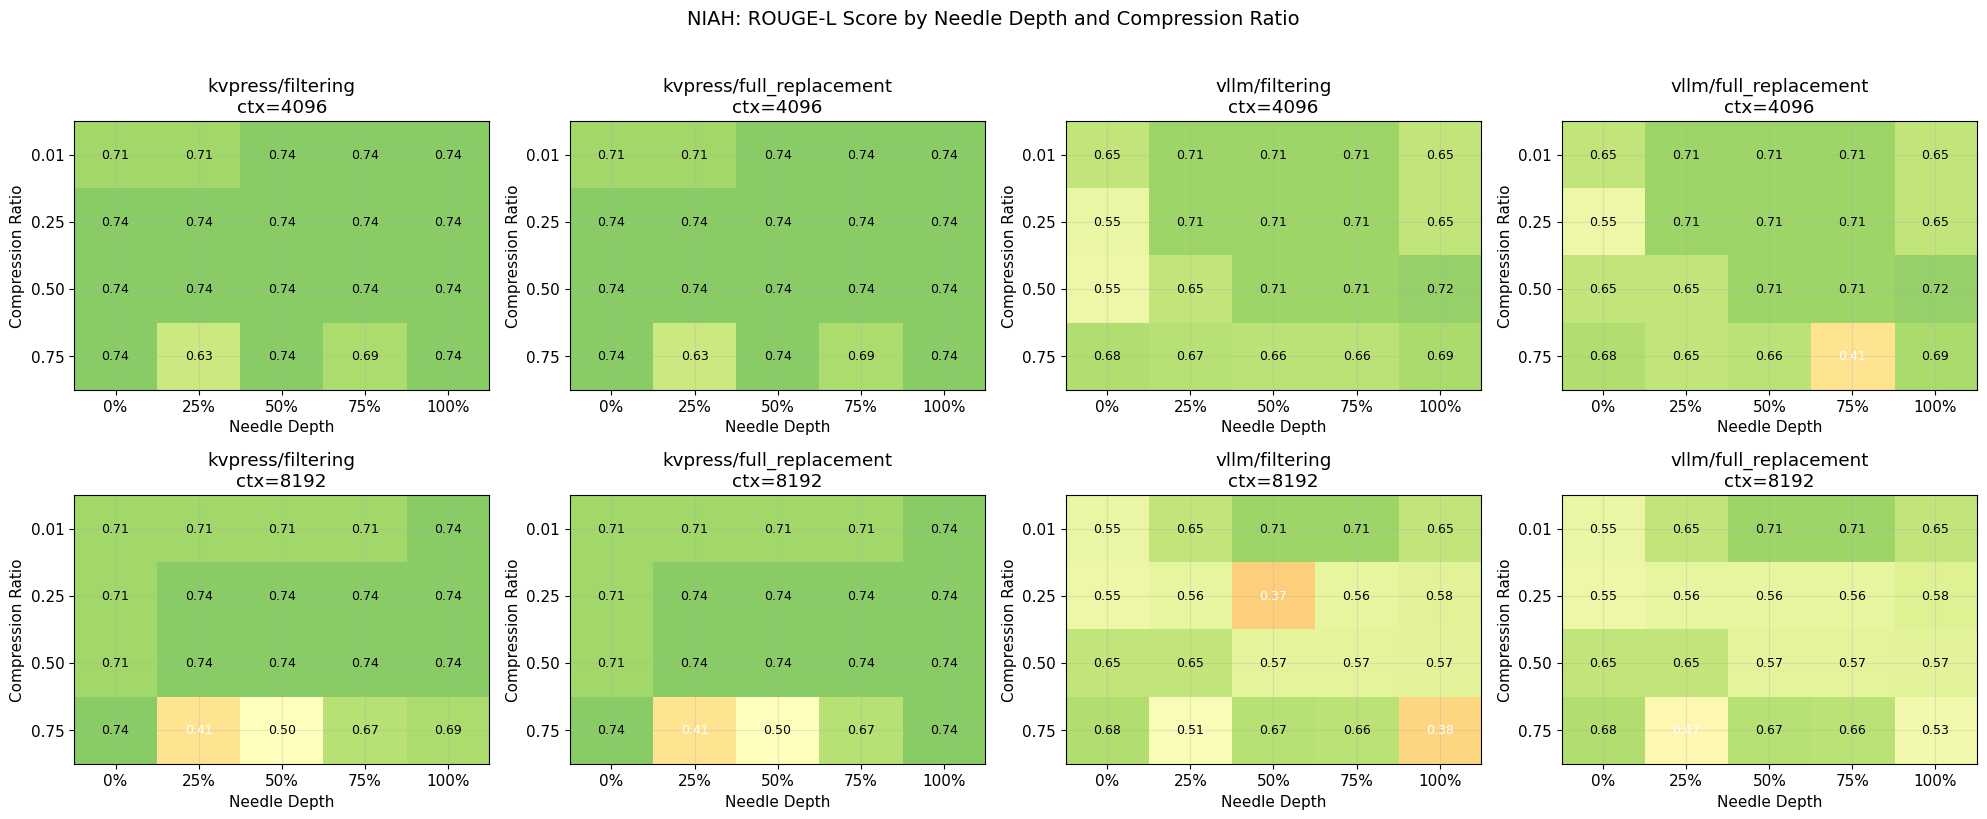

In [3]:
combos = df.groupby(["framework", "press"]).size().reset_index()[["framework", "press"]]
combo_list = list(combos.itertuples(index=False, name=None))
context_lengths = sorted(df["max_context_length"].unique())

n_cols = len(combo_list)
n_rows = len(context_lengths)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    squeeze=False,
)

for row_idx, ctx_len in enumerate(context_lengths):
    for col_idx, (fw, press_name) in enumerate(combo_list):
        sub = df[
            (df["framework"] == fw)
            & (df["press"] == press_name)
            & (df["max_context_length"] == ctx_len)
        ]
        if sub.empty:
            axes[row_idx, col_idx].set_visible(False)
            continue

        depths = sorted(sub["needle_depth"].unique())
        ratios = sorted(sub["compression_ratio"].unique())

        heatmap_data = np.zeros((len(ratios), len(depths)))
        for i, r in enumerate(ratios):
            for j, d in enumerate(depths):
                cell = sub[(sub["compression_ratio"] == r) & (sub["needle_depth"] == d)]
                heatmap_data[i, j] = cell["rouge_l_f"].mean() if not cell.empty else 0

        ax = axes[row_idx, col_idx]
        ax.imshow(heatmap_data, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
        ax.set_xticks(range(len(depths)))
        ax.set_xticklabels([f"{d}%" for d in depths])
        ax.set_yticks(range(len(ratios)))
        ax.set_yticklabels([f"{r:.2f}" for r in ratios])
        ax.set_xlabel("Needle Depth")
        ax.set_ylabel("Compression Ratio")
        ax.set_title(f"{fw}/{press_name}\nctx={ctx_len}")

        for i in range(len(ratios)):
            for j in range(len(depths)):
                val = heatmap_data[i, j]
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9,
                        color="white" if val < 0.5 else "black")

fig.suptitle("NIAH: ROUGE-L Score by Needle Depth and Compression Ratio", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig("results/niah_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Memory Comparison — Peak GPU Memory

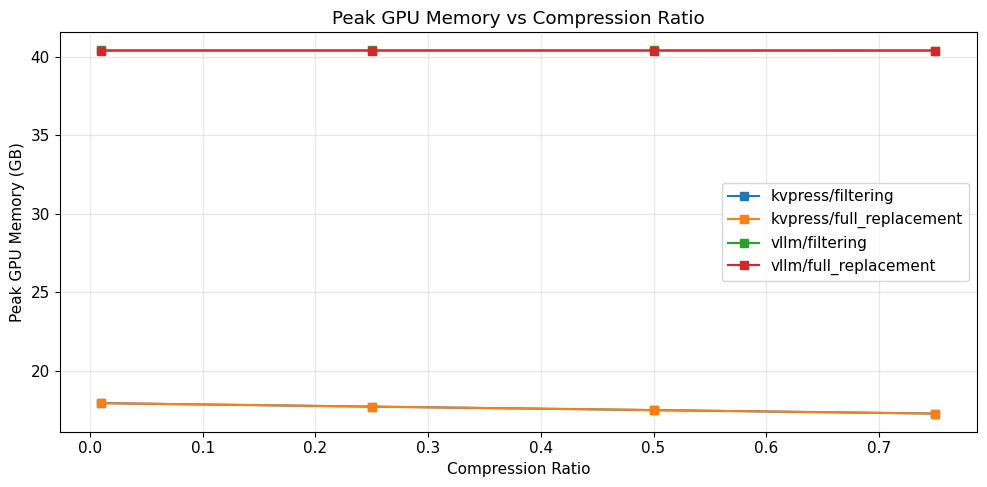

In [4]:
memory = (
    df.groupby(["framework", "press", "compression_ratio"])
    .agg(mean_mem=("peak_gpu_mem_gb", "mean"))
    .round(3)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))

for (fw, press_name), sub in memory.groupby(["framework", "press"]):
    ax.plot(
        sub["compression_ratio"], sub["mean_mem"],
        marker="s", label=f"{fw}/{press_name}",
    )

ax.set_xlabel("Compression Ratio")
ax.set_ylabel("Peak GPU Memory (GB)")
ax.set_title("Peak GPU Memory vs Compression Ratio")
ax.legend()
fig.tight_layout()
fig.savefig("results/memory_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Latency Comparison — Inference Time per Sample

/tmp/ipykernel_86588/3449673879.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels, patch_artist=True)


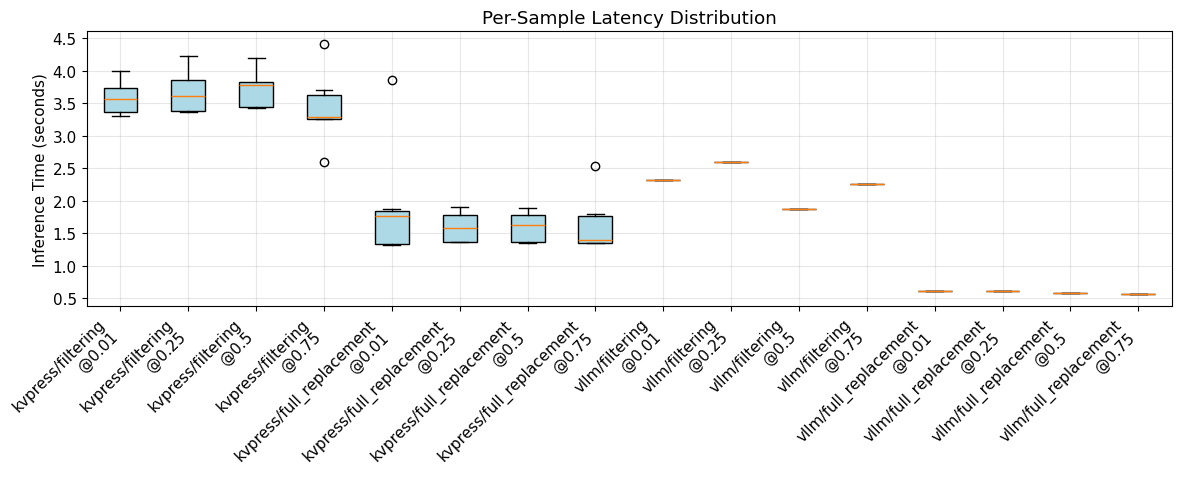

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

groups = []
labels = []

for (fw, press_name), fw_sub in df.groupby(["framework", "press"]):
    for ratio in sorted(fw_sub["compression_ratio"].unique()):
        sub = fw_sub[fw_sub["compression_ratio"] == ratio]
        if not sub.empty:
            groups.append(sub["elapsed_sec"].values)
            labels.append(f"{fw}/{press_name}\n@{ratio}")

bp = ax.boxplot(groups, labels=labels, patch_artist=True)

for i, patch in enumerate(bp["boxes"]):
    if labels[i].startswith("vllm/"):
        patch.set_facecolor("lightcoral")
    else:
        patch.set_facecolor("lightblue")

ax.set_ylabel("Inference Time (seconds)")
ax.set_title("Per-Sample Latency Distribution")
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
fig.savefig("results/latency_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Summary Table

In [6]:
summary = (
    df.groupby(["framework", "press", "compression_ratio"])
    .agg(
        avg_rouge_l=("rouge_l_f", "mean"),
        avg_time_sec=("elapsed_sec", "mean"),
        avg_mem_gb=("peak_gpu_mem_gb", "mean"),
        n_samples=("rouge_l_f", "count"),
    )
    .round(4)
)

print("\n" + "=" * 80)
print("OVERALL SUMMARY")
print("=" * 80)
print(summary.to_string())


OVERALL SUMMARY
                                              avg_rouge_l  avg_time_sec  avg_mem_gb  n_samples
framework press            compression_ratio                                                  
kvpress   filtering        0.01                    0.7207        3.5878     17.9195         10
                           0.25                    0.7392        3.6730     17.6994         10
                           0.50                    0.7392        3.7181     17.4779         10
                           0.75                    0.6552        3.4222     17.2560         10
          full_replacement 0.01                    0.7207        1.8247     17.9195         10
                           0.25                    0.7392        1.5912     17.6994         10
                           0.50                    0.7392        1.5977     17.4779         10
                           0.75                    0.6609        1.6008     17.2560         10
vllm      filtering        0.01  

## 6. Key Findings

*(Fill in after running the experiments)*

**Retrieval Quality (NIAH):**
- At 0% compression, kvpress/KeyDiffPress matches the vLLM baseline.
- As compression increases, retrieval accuracy may degrade — especially
  at certain needle depths where the evicted tokens contained the needle.
- BlockPress (block-wise iterative) vs plain KeyDiffPress may show different
  depth-sensitivity patterns.

**Memory:**
- Higher compression ratios reduce peak GPU memory.
- vLLM's PagedAttention is memory-efficient but does not compress.

**Latency:**
- vLLM with continuous batching is faster for batch inference.
- kvpress incurs per-layer compression overhead.

**Implications for KeyDiff in vLLM:**
- Combining vLLM's throughput with KeyDiff compression could yield both
  high throughput and reduced memory — the thesis objective.